In [ ]:
!pip install trl==0.11.4 transformers accelerate datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.6/316.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 10.8 MB/s eta 0:00:00


In [ ]:
import os, time
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, pipeline, set_seed
from trl import PPOConfig, PPOTrainer, AutoModelForCausalLMWithValueHead, create_reference_model

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(42)
print("device:", device)

device: cuda


In [ ]:
base_model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.padding_side = 'left'
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLMWithValueHead.from_pretrained(base_model_name).to(device)
ref_model = create_reference_model(model)

print("Loaded:", base_model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loaded: distilgpt2


In [ ]:
reward_model_name = "lvwerra/distilbert-imdb"
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=reward_model_name,
    device=0 if device == "cuda" else -1,
    truncation=True,
    max_length=512,
    top_k=None,              # [FIX 2] return_all_scores=True is deprecated; use top_k=None
    function_to_apply="none",
)

def compute_rewards(text_list, scale=1.0):
    outs = sentiment_pipe(text_list, batch_size=16)
    rewards = []
    for o in outs:
        score_map = {d["label"].upper(): float(d["score"]) for d in o}
        pos = score_map.get("POSITIVE", score_map.get("LABEL_1", 0.0))
        neg = score_map.get("NEGATIVE", score_map.get("LABEL_0", 0.0))
        r = (pos - neg) * scale
        rewards.append(r)
    return rewards

print(compute_rewards(["I loved it!", "I hated it!"]))

config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[5.087319374084473, -2.9498512744903564]


In [ ]:
raw = load_dataset("imdb", split="train").shuffle(seed=42).select(range(2000))

def build_prompt(ex, max_chars=200):
    snippet = ex["text"].replace("\n", " ").strip()[:max_chars]
    prompt = (
        "Write a movie review in a clearly POSITIVE tone about the following content.\n"
        f"Content: {snippet}\n"
        "Positive Review:"
    )
    return {"prompt": prompt}

ds = raw.map(build_prompt, remove_columns=raw.column_names)

max_prompt_len = 256
def tokenize_fn(ex):
    out = tokenizer(ex["prompt"], truncation=True, max_length=max_prompt_len, padding=False)
    return out

ds = ds.map(tokenize_fn, remove_columns=["prompt"])
ds.set_format(type="torch")
print(ds[0].keys(), len(ds))

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'attention_mask']) 2000


In [ ]:
ppo_config = PPOConfig(
    learning_rate=1e-6,
    batch_size=8,
    mini_batch_size=4,
    ppo_epochs=4,
    gradient_accumulation_steps=1,
    target_kl=0.2,

)

def collator(data):
    return tokenizer.pad(data, padding=True, return_tensors="pt")

ppo_trainer = PPOTrainer(
    config=ppo_config,
    model=model,
    ref_model=ref_model,
    tokenizer=tokenizer,
    dataset=ds,
    data_collator=collator,
)

print("PPOTrainer ready. Steps:", len(ppo_trainer.dataloader))

PPOTrainer ready. Steps: 250


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_config.py:207: FutureWarning: `PPOConfig` is deprecated and will be removed in the future. Please use `PPOv2Config` with `PPOv2Trainer` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:193: FutureWarning: `PPOTrainer` is deprecated and will be removed in trl v0.12. Please use `PPOv2Trainer` instead.
  warnings.warn(


In [ ]:
def generate_samples(prompts, max_new_tokens=80):
    model.eval()
    outs = []
    for p in prompts:
        inputs = tokenizer(p, return_tensors="pt", truncation=True, max_length=max_prompt_len).to(device)
        with torch.no_grad():
            gen = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                top_p=0.95,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )
        prompt_len = inputs["input_ids"].shape[-1]
        completion_ids = gen[0, prompt_len:]
        outs.append(tokenizer.decode(completion_ids, skip_special_tokens=True).strip())
    return outs

sample_prompts = [
    "Write a movie review in a clearly POSITIVE tone about the following content.\nContent: A story about a family overcoming hardships.\nPositive Review:",
    "Write a movie review in a clearly POSITIVE tone about the following content.\nContent: An action movie with a hero saving the city.\nPositive Review:",
]

before = generate_samples(sample_prompts)
before_r = compute_rewards(before)
for i,(t,r) in enumerate(zip(before,before_r),1):
    print("="*80)
    print(f"[BEFORE {i}] reward={r:+.4f}\n{t[:900]}")
print("mean before:", sum(before_r)/len(before_r))

[BEFORE 1] reward=+3.1690
How to write your own books.
Comments: We have been asking for readers to write their own books from the perspective of a reader that has always believed that the book could be the best reading experience ever. That is, it may not be a good feeling, but it is something we can talk about and have a plan for how to write. Here is a few examples of how you can help
[BEFORE 2] reward=+2.1419
A story of a friend's life in the city when someone is hurt or is in the city. A story that doesn't mention the city in the video.
Negative Review: A story about an incident in the city when somebody's car is damaged.
Positive Review: A story about a friend's life in the city when someone is hurt or is in the city.
If you
mean before: 2.655454635620117


In [ ]:
import time
import numpy as np

class LengthSampler:
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value
    def __call__(self):
        return np.random.randint(self.min_value, self.max_value)

model = model.to(device)

output_min_length = 8
output_max_length = 24
output_length_sampler = LengthSampler(output_min_length, output_max_length)

generation_kwargs = dict(
    min_length=-1,
    do_sample=True,
    top_p=0.9,
    temperature=0.7,
    pad_token_id=tokenizer.eos_token_id,
)

total_steps = 200
t0 = time.time()
model.train()

for step, batch in enumerate(ppo_trainer.dataloader):
    if step >= total_steps:
        break

    input_ids = batch["input_ids"].to(device)
    attn = batch["attention_mask"].to(device)
    query_tensors = [ids[mask.bool()] for ids, mask in zip(input_ids, attn)]

    gen_len = output_length_sampler()
    generation_kwargs["max_new_tokens"] = gen_len

    t_gen0 = time.time()
    outs = ppo_trainer.generate(query_tensors, return_prompt=False, **generation_kwargs)
    t_gen1 = time.time()

    if isinstance(outs, torch.Tensor):
        outs = [x for x in outs]

    response_tensors = [out.reshape(-1) for out in outs]

    gen_texts = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

    t_rw0 = time.time()
    rewards = compute_rewards(gen_texts)
    t_rw1 = time.time()

    rewards_tensors = [torch.tensor(float(r), device=device) for r in rewards]

    stats = ppo_trainer.step(query_tensors, response_tensors, rewards_tensors)

    mean_reward = float(np.mean(rewards))
    if step % 5 == 0:
        kl = stats.get("objective/kl", stats.get("ppo/mean_non_score_reward", None))
        if kl is None:
            print(f"step={step:04d} mean_reward={mean_reward:+.4f} gen={t_gen1-t_gen0:.2f}s reward={t_rw1-t_rw0:.2f}s")
        else:
            print(f"step={step:04d} mean_reward={mean_reward:+.4f} kl={float(kl):+.4f} gen={t_gen1-t_gen0:.2f}s reward={t_rw1-t_rw0:.2f}s")

print("done, time:", round(time.time() - t0, 1), "s")

step=0000 mean_reward=+3.9345 kl=+3.6218 gen=1.31s reward=0.03s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -4.91 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0005 mean_reward=+3.3948 kl=+1.8957 gen=0.28s reward=0.01s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.15 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.83 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -6.65 - this might be a precursor for failed training. sometimes this happens because the generation

step=0010 mean_reward=+2.5999 kl=-0.0310 gen=0.17s reward=0.01s
step=0015 mean_reward=+3.9657 kl=+2.8714 gen=0.37s reward=0.01s


...

step=0160 mean_reward=+2.2975 kl=-0.5309 gen=0.21s reward=0.01s
step=0165 mean_reward=+4.5832 kl=+0.9209 gen=0.27s reward=0.01s
step=0170 mean_reward=+4.9108 kl=+1.1547 gen=0.33s reward=0.01s
step=0175 mean_reward=+4.2723 kl=+4.2499 gen=0.18s reward=0.01s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.17 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0180 mean_reward=+4.2084 kl=-1.1663 gen=0.18s reward=0.01s


/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -3.17 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/ppo_trainer.py:1313: UserWarning: KL divergence is starting to become negative: -1.21 - this might be a precursor for failed training. sometimes this happens because the generation kwargs are not correctly set. Please make sure that the generation kwargs are set correctly, or review your training hyperparameters.
  warnings.warn(


step=0185 mean_reward=+3.9396 kl=-1.2124 gen=0.31s reward=0.01s
step=0190 mean_reward=+4.5525 kl=-0.8343 gen=0.35s reward=0.01s
step=0195 mean_reward=+4.2022 kl=+2.2018 gen=0.26s reward=0.01s
done, time: 236.6 s


In [ ]:
after = generate_samples(sample_prompts)
after_r = compute_rewards(after)
for i,(t,r) in enumerate(zip(after,after_r),1):
    print("="*80)
    print(f"[AFTER {i}] reward={r:+.4f}\n{t[:900]}")

print("mean before:", sum(before_r)/len(before_r))
print("mean after :", sum(after_r)/len(after_r))

[AFTER 1] reward=+4.9629
A story about a very tough, tough life.
Review: A story about a very tough, tough life. Content: A short story about a strong life.
Submitting a review to this post
You must be logged in to post a comment. For other users, be sure to log in. If you have an account you can post it on the comments section of the website. Thanks
[AFTER 2] reward=+3.9277
An action movie with a hero saving the city.
The following content in this guide is taken from the book we published from the year 2009. It shows how to improve the quality of content to a consistent, balanced, and satisfying quality.
The following elements show how to improve the quality of content to a consistent, balanced, and satisfying quality. This guide has not gone through a ton of detail
mean before: 2.655454635620117
mean after : 4.445271909236908


In [ ]:
save_dir = "rlhf_positive_gpt2_trl"
os.makedirs(save_dir, exist_ok=True)
ppo_trainer.model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print("Saved:", save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: rlhf_positive_gpt2_trl


In [ ]:
import torch
import numpy as np
from datasets import load_dataset

model = model.to(device)
ref_model = ref_model.to(device)

def build_prompt_eval(text, max_chars=200):
    snippet = text.replace("\n", " ").strip()[:max_chars]
    return (
        "Write a movie review in a clearly POSITIVE tone about the following content.\n"
        f"Content: {snippet}\n"
        "Positive Review:"
    )

EVAL_N = 200
test_ds = load_dataset("imdb", split="test").shuffle(seed=123).select(range(EVAL_N))
eval_prompts = [build_prompt_eval(t) for t in test_ds["text"]]

@torch.no_grad()
def generate_from(model_obj, prompts, max_prompt_len=256, max_new_tokens=80, batch_size=8):
    model_obj.eval()
    outputs = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        enc = tokenizer(
            batch_prompts,
            return_tensors="pt",
            truncation=True,
            max_length=max_prompt_len,
            padding=True,
        ).to(device)
        gen = model_obj.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            top_p=0.95,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
        prompt_len = enc["input_ids"].shape[-1]
        completion_ids = gen[:, prompt_len:]
        outputs.extend(t.strip() for t in tokenizer.batch_decode(completion_ids, skip_special_tokens=True))
    return outputs

baseline_texts = generate_from(ref_model, eval_prompts, max_new_tokens=80, batch_size=8)
trained_texts  = generate_from(model, eval_prompts, max_new_tokens=80, batch_size=8)

baseline_rewards = np.array(compute_rewards(baseline_texts), dtype=np.float32)
trained_rewards  = np.array(compute_rewards(trained_texts), dtype=np.float32)
delta = trained_rewards - baseline_rewards

print("Eval size:", len(eval_prompts))
print("Baseline mean reward:", float(baseline_rewards.mean()))
print("Trained   mean reward:", float(trained_rewards.mean()))
print("Mean delta (trained - baseline):", float(delta.mean()))

Eval size: 200
Baseline mean reward: 1.5290640592575073
Trained   mean reward: 4.702292442321777
Mean delta (trained - baseline): 3.1732282638549805


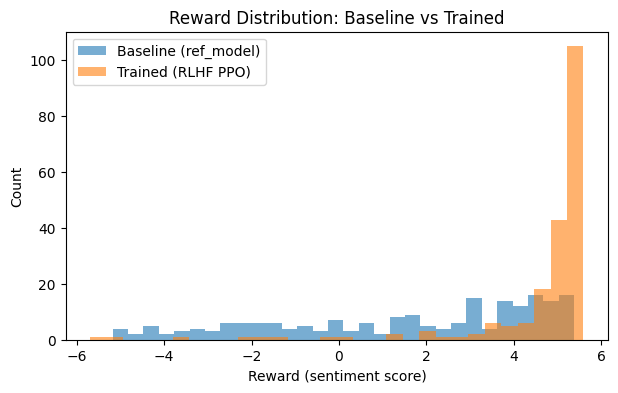

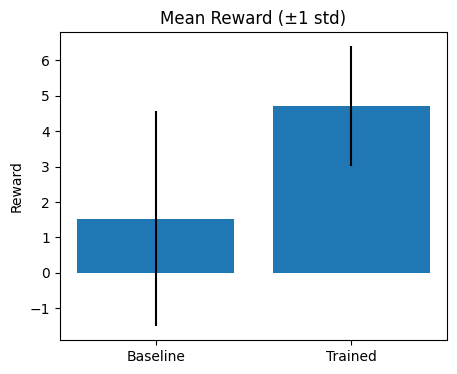

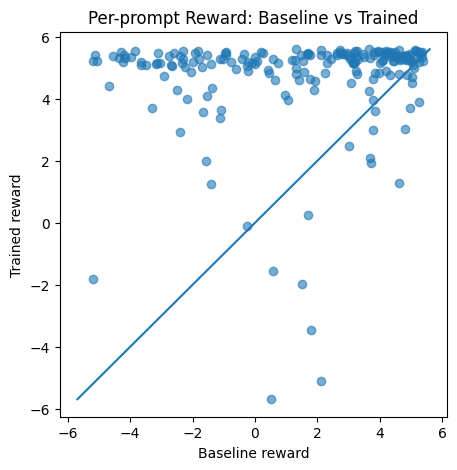

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4))
plt.hist(baseline_rewards, bins=30, alpha=0.6, label="Baseline (ref_model)")
plt.hist(trained_rewards,  bins=30, alpha=0.6, label="Trained (RLHF PPO)")
plt.xlabel("Reward (sentiment score)")
plt.ylabel("Count")
plt.title("Reward Distribution: Baseline vs Trained")
plt.legend()
plt.show()

means = [baseline_rewards.mean(), trained_rewards.mean()]
stds  = [baseline_rewards.std(),  trained_rewards.std()]

plt.figure(figsize=(5,4))
plt.bar(["Baseline", "Trained"], means, yerr=stds)
plt.ylabel("Reward")
plt.title("Mean Reward (\u00b11 std)")
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(baseline_rewards, trained_rewards, alpha=0.6)
mn = float(min(baseline_rewards.min(), trained_rewards.min()))
mx = float(max(baseline_rewards.max(), trained_rewards.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Baseline reward")
plt.ylabel("Trained reward")
plt.title("Per-prompt Reward: Baseline vs Trained")
plt.show()

In [ ]:
import numpy as np
import textwrap

top_k = 5
top_idx = np.argsort(-delta)[:top_k]

for rank, idx in enumerate(top_idx, 1):
    prompt_snip = eval_prompts[idx].split("Content:",1)[-1].split("\nPositive Review:",1)[0].strip()

    print("="*100)
    print(f"[TOP IMPROVEMENT #{rank}] idx={idx}")
    print(f"Baseline reward: {baseline_rewards[idx]:+.4f}")
    print(f"Trained  reward: {trained_rewards[idx]:+.4f}")
    print(f"Delta          : {delta[idx]:+.4f}")
    print("-"*100)
    print("PROMPT (content snippet):")
    print(textwrap.fill(prompt_snip[:300], width=100))
    print("-"*100)
    print("BASELINE OUTPUT:")
    print(baseline_texts[idx][:1000])
    print("-"*100)
    print("TRAINED OUTPUT:")
    print(trained_texts[idx][:1000])

[TOP IMPROVEMENT #1] idx=55
Baseline reward: -5.1407
Trained  reward: +5.4270
Delta          : +10.5677
----------------------------------------------------------------------------------------------------
PROMPT (content snippet):
Ineffectual, molly-coddled, self-pitying, lousy provider Jimmy Stewart is having a bad marriage to
Carole Lombard. After falling on hard times, he endures a demeaning job, a fault-finding, passive-
agg
----------------------------------------------------------------------------------------------------
BASELINE OUTPUT:
What if she doesn't come from the same place as Carole Lombard? How much does it take to make a movie that would make the world a better place? Or is it the same business model?
Ineffectual, Molly-coddled, self-pitying, lousy provider Jimmy Stewart is having a bad marriage to Carole Lombard. After falling on hard times
----------------------------------------------------------------------------------------------------
TRAINED OUTPUT:
This episod

In [ ]:
import pandas as pd
import textwrap

def bert_classify(text_list):
    """Use DistilBERT to output (label, confidence, pos-neg margin) for each text entry."""
    outs = sentiment_pipe(text_list, batch_size=16)
    results = []
    for o in outs:
        score_map = {d["label"].upper(): float(d["score"]) for d in o}
        pos = score_map.get("POSITIVE", score_map.get("LABEL_1", 0.0))
        neg = score_map.get("NEGATIVE", score_map.get("LABEL_0", 0.0))
        label = "POSITIVE" if pos >= neg else "NEGATIVE"
        confidence = max(pos, neg)
        margin = pos - neg
        results.append((label, confidence, margin))
    return results

N_TABLE = min(20, len(eval_prompts))
assert N_TABLE >= 15, f"At least 15 items are required, but eval_prompts contains only {len(eval_prompts)} items."

base_cls = bert_classify(baseline_texts[:N_TABLE])
trn_cls  = bert_classify(trained_texts[:N_TABLE])

rows = []
for i in range(N_TABLE):
    snippet = eval_prompts[i].split("Content:", 1)[-1].split("\nPositive Review:", 1)[0].strip()
    if base_cls[i][0] == "NEGATIVE" and trn_cls[i][0] == "POSITIVE":
        flip = "NEG→POS"
    elif base_cls[i][0] == "POSITIVE" and trn_cls[i][0] == "NEGATIVE":
        flip = "POS→NEG"
    else:
        flip = ""
    rows.append({
        "idx": i,
        "prompt": (snippet[:55] + "...") if len(snippet) > 55 else snippet,
        "before_label": base_cls[i][0],
        "before_conf":  round(base_cls[i][1], 3),
        "before_rwd":   round(float(baseline_rewards[i]), 3),
        "after_label":  trn_cls[i][0],
        "after_conf":   round(trn_cls[i][1], 3),
        "after_rwd":    round(float(trained_rewards[i]), 3),
        "delta":        round(float(delta[i]), 3),
        "flip":         flip,
    })

df = pd.DataFrame(rows)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)
print(f"BERT (DistilBERT-IMDB) before/after Comparative analysis table (total {len(df)} entries）")
print("=" * 120)
print(df.to_string(index=False))
print("=" * 120)

flips_n2p = int(((df["before_label"] == "NEGATIVE") & (df["after_label"] == "POSITIVE")).sum())
flips_p2n = int(((df["before_label"] == "POSITIVE") & (df["after_label"] == "NEGATIVE")).sum())
both_pos  = int(((df["before_label"] == "POSITIVE") & (df["after_label"] == "POSITIVE")).sum())
both_neg  = int(((df["before_label"] == "NEGATIVE") & (df["after_label"] == "NEGATIVE")).sum())
improved  = int((df["delta"] > 0).sum())

print("Summary Statistics:")
print(f"  NEG → POS Inversion: {flips_n2p:>3d} / {len(df)}")
print(f"  POS → NEG Inversion: {flips_p2n:>3d} / {len(df)}")
print(f"  Always Positive: {both_pos:>3d} / {len(df)}")
print(f"  Always NEGATIVE  : {both_neg:>3d} / {len(df)}")
print(f"  Increase in Reward Count: {improved:>3d} / {len(df)}")
print(f"  Average before reward = {df['before_rwd'].mean():+.4f}")
print(f"  Average after  reward = {df['after_rwd'].mean():+.4f}")
print(f"  Average delta         = {df['delta'].mean():+.4f}")

try:
    from IPython.display import display
    display(df)
except Exception:
    pass

print("\nDetailed Before/After Text Comparison (Top 5 Entries)")
print("=" * 120)
for i in range(min(5, N_TABLE)):
    print(f"\n[#{i}]  before={base_cls[i][0]}({base_cls[i][1]:.3f})  "
          f"after={trn_cls[i][0]}({trn_cls[i][1]:.3f})  delta={float(delta[i]):+.4f}")
    print("BEFORE:", textwrap.shorten(baseline_texts[i].replace("\n", " "), width=320, placeholder=" ..."))
    print("AFTER :", textwrap.shorten(trained_texts[i].replace("\n", " "), width=320, placeholder=" ..."))

BERT (DistilBERT-IMDB) before/after Comparative analysis table (total 20 entries）
 idx                                                     prompt before_label  before_conf  before_rwd after_label  after_conf  after_rwd  delta    flip
   0 Whatever you do, don't stop watching when you think the...     NEGATIVE        1.088      -2.580    POSITIVE       2.866      5.471  8.051 NEG→POS
   1 Maybe we Aussies just have a totally different sense of...     POSITIVE        0.849       1.692    POSITIVE       2.857      5.438  3.747        
   2 Well as the headline suggests this is not the particula...     POSITIVE        0.189       0.412    POSITIVE       2.587      4.931  4.519        
   3 www.petitiononline.com/19784444/petition.html An excell...     POSITIVE        2.714       5.189    POSITIVE       2.884      5.535  0.346        
   4 I don't think I really have any spoilers in here but si...     POSITIVE        2.513       4.819    POSITIVE       1.593      3.039 -1.780        
   5 W

,idx,prompt,before_label,before_conf,before_rwd,after_label,after_conf,after_rwd,delta,flip
0,0,"Whatever you do, don't stop watching when you think the...",NEGATIVE,1.088,-2.580,POSITIVE,2.866,5.471,8.051,NEG→POS
1,1,Maybe we Aussies just have a totally different sense of...,POSITIVE,0.849,1.692,POSITIVE,2.857,5.438,3.747,
2,2,Well as the headline suggests this is not the particula...,POSITIVE,0.189,0.412,POSITIVE,2.587,4.931,4.519,
3,3,www.petitiononline.com/19784444/petition.html An excell...,POSITIVE,2.714,5.189,POSITIVE,2.884,5.535,0.346,
4,4,I don't think I really have any spoilers in here but si...,POSITIVE,2.513,4.819,POSITIVE,1.593,3.039,-1.780,
5,5,When I first heared that there was going to be The Worl...,POSITIVE,2.632,5.046,POSITIVE,2.385,4.513,-0.533,
6,6,"So, you wanna be a rock star? See this movie. You don't...",POSITIVE,1.981,3.812,POSITIVE,2.899,5.513,1.701,
7,7,This is a film that every child should see before they ...,POSITIVE,1.855,3.482,POSITIVE,2.814,5.346,1.864,
8,8,"Reality before reality TV? Copy of ""Fast Times at Ridge...",NEGATIVE,1.626,-3.661,POSITIVE,2.694,5.100,8.761,NEG→POS
9,9,"And you'd be right. Black Mama, White Mama, also known ...",POSITIVE,0.764,1.553,POSITIVE,2.738,5.213,3.660,



Detailed Before/After Text Comparison (Top 5 Entries)

[#0]  before=NEGATIVE(1.088)  after=POSITIVE(2.866)  delta=+8.0512
BEFORE: No! (No) It's a movie review. I had to stop watching it until it was over, so I'm not going to be watching it.
AFTER : The film was an absolutely amazing film by a talented group, with the sheer enthusiasm and excitement it presented! The film did a tremendous job of making and editing the best of any film. The cinematography and the music really made it a beautiful film! Enjoy! Share this: Facebook

[#1]  before=POSITIVE(0.849)  after=POSITIVE(2.857)  delta=+3.7466
BEFORE: Maybe I've never seen a film where that would What I have heard to say is that a movie review is a way for people to start thinking and feeling a bit better about their lives. What can I say? I would always think of a movie review at the beginning. So, what I am saying here is that I am not going to tell the world ...
AFTER : This movie is absolutely beautiful, it's pretty stunning and f

In [ ]:
model.save_pretrained("ppo_positive_imdb")
tokenizer.save_pretrained("ppo_positive_imdb")
print("Final model saved to ppo_positive_imdb/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to ppo_positive_imdb/
